# Compute the frequency spectrum of a timeseries

This notebook demonstrates how to compute the discrete Fourier Transform (FFT) of a timeseries using `temporal.fft`. The time dimension is detected automatically and the returned frequency coordinate is expressed in Hz (cycles per second). We use a short hourly 2m temperature dataset for two locations (Reading and Vancouver), each with a strong diurnal (24-hour) cycle, to show that the transform and the downstream analysis work when the data contains more than one time-series.


In [1]:
import numpy as np

from earthkit import data as ekd
from earthkit import transforms as ekt

# Hourly 2m temperature timeseries for two locations (72 hourly steps, 3 days)
ds = ekd.from_source("sample", "era5-timeseries-multiple.nc").to_xarray()
da = ds["t2m"]  # .sel(location="Reading")

da

<xarray.DataArray 't2m' (valid_time: 72, location: 2)> Size: 576B
[144 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 576B 2026-05-23 ... 2026-05-25T23...
  * location    (location) <U9 72B 'Reading' 'Vancouver'
    latitude    (location) float64 16B ...
    longitude   (location) float64 16B ...
    utc_offset  (location) timedelta64[s] 16B ...
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

## Compute the FFT

`temporal.fft` detects the time dimension (`valid_time`) automatically and returns a complex-valued result indexed by a `frequency` dimension. The frequency coordinate is derived from the hourly sampling and expressed in Hz.

In [2]:
spectrum = ekt.temporal.fft(da)

spectrum

<xarray.DataArray 't2m' (location: 2, frequency: 72)> Size: 1kB
array([[ 2.1254309e+04+0.0000000e+00j,  3.6181873e+01+8.3899078e+01j,
         1.8603952e+01+3.0636444e+01j, -1.9632404e+02+1.7992714e+02j,
         1.4326304e-01-1.8276188e+01j,  2.1387093e-02-3.5564790e+00j,
         1.5857482e+00+7.8525548e+00j, -8.0988111e+00-1.5550503e-01j,
        -9.4715452e+00+3.8258581e+00j,  1.0177716e+01-1.7595097e+01j,
         3.9469767e-01+5.0195365e+00j, -6.0290465e+00+3.9161768e+00j,
         4.1107635e+00-3.0908978e+00j, -1.7498523e+00+1.9973781e+00j,
        -1.5209463e+00+3.6424193e-01j, -4.9151093e-01+2.5865140e+00j,
        -3.2336328e+00+1.4347422e+00j, -8.6006445e-01+6.3981169e-01j,
        -4.4917297e+00+5.6923523e+00j, -6.9665194e-01+1.0354474e+00j,
        -2.8036752e+00+8.2415718e-01j, -2.4032340e+00+1.9318168e+00j,
        -1.5208218e+00+3.7614647e-01j, -3.4489987e+00+6.1524749e-01j,
        -2.9255829e+00-4.9863592e-01j, -2.0512412e+00+1.5625035e+00j,
        -2.7773783e+00+9.0367144e-01j, -1.7438781e+00+6.6997933e-01j,
        -2.3840063e+00+1.4095925e+00j, -1.4071045e+00+4.2337486e-01j,
        -2.3490539e+00+3.8001978e-01j, -1.9792778e+00+1.1325877e+00j,
        -1.9649117e+00+8.0021866e-02j, -2.6341197e+00+1.8611387e+00j,
        -1.6150200e+00+3.7647539e-01j, -2.0705647e+00+2.7284950e-01j,
        -1.4873657e+00+0.0000000e+00j, -2.0705647e+00-2.7284950e-01j,
        -1.6150200e+00-3.7647539e-01j, -2.6341197e+00-1.8611387e+00j,
...
         3.3342636e+00-7.5709748e-01j,  3.9378946e+00-3.4953864e+00j,
         7.0458374e+00+0.0000000e+00j,  3.9378946e+00+3.4953864e+00j,
         3.3342636e+00+7.5709748e-01j,  4.1351085e+00+5.7629734e-01j,
         6.5165482e+00+4.2519426e+00j,  5.2331686e+00+1.1988643e+00j,
         4.1306710e+00-6.4817798e-01j,  5.9292765e+00+1.3905396e+00j,
         6.2371111e+00+4.1921296e+00j,  2.4984152e+00+1.4556694e+00j,
         6.0015163e+00-9.3847111e-02j,  8.3524342e+00+1.7980209e-01j,
         5.0460968e+00+1.2276534e+00j, -7.9135495e-01-3.3581141e-01j,
         2.5643332e+00+2.1924560e+00j,  4.8464308e+00+4.2031631e+00j,
         1.2470086e+00+4.9645925e+00j,  3.0266280e+00+4.8894978e+00j,
         2.4633484e+00+4.8388977e+00j,  5.9868159e+00+9.7102814e+00j,
         4.1866784e+00+9.8468170e+00j,  7.3318734e+00+7.1961112e+00j,
         1.2184740e+01+3.8871851e+00j,  3.8162334e+00+7.8611465e+00j,
         2.4574432e+00+8.2752104e+00j,  4.1127281e+00+1.3927075e+01j,
         2.9748662e+00+9.7654457e+00j,  8.7244854e+00+1.8474651e+01j,
         4.5798087e+00+9.3347626e+00j, -1.0071405e+00+1.3520410e+01j,
         7.6392264e+00+2.5833572e+01j,  6.9707084e+00+3.3821907e+01j,
         1.0047634e+01+3.6517815e+01j,  1.0002118e+02+3.7337396e+00j,
        -2.1079220e+01+1.4808721e+01j,  1.6877066e+01-4.4522767e+00j]],
      dtype=complex64)
Coordinates:
  * location    (location) <U9 72B 'Reading' 'Vancouver'
    latitude    (location) float64 16B ...
    longitude   (location) float64 16B ...
    utc_offset  (location) timedelta64[s] 16B ...
  * frequency   (frequency) float64 576B 0.0 3.858e-06 ... -7.716e-06 -3.858e-06
    period      (frequency) float64 576B nan 2.592e+05 ... -1.296e+05 -2.592e+05
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

## Identify the dominant period

We keep the positive frequencies and compute the amplitude of each frequency component. `temporal.fft` attaches a convenience `period` coordinate (`1 / frequency`, in seconds) alongside the frequency coordinate, so we can read the dominant cycle directly instead of converting from Hz by hand. Because the spectrum retains the `location` dimension, we use `argmax` along the `frequency` dimension to find the dominant cycle independently for each time-series.


In [3]:
# Keep positive frequencies only (drop the zero-frequency/mean component)
positive = spectrum.where(spectrum["frequency"] > 0, drop=True)
amplitude = np.abs(positive)

# The `period` coordinate is in seconds; express it in hours for readability
period_hours = positive["period"] / 3600.0
amplitude = amplitude.assign_coords(period_hours=("frequency", period_hours.data))

# Dominant period for each timeseries (one per location)
dominant_period = period_hours.isel(frequency=amplitude.argmax("frequency"))
for location in dominant_period["location"].values:
    period = float(dominant_period.sel(location=location))
    print(f"{location}: dominant period {period:.1f} hours")

Reading: dominant period 24.0 hours
Vancouver: dominant period 24.0 hours


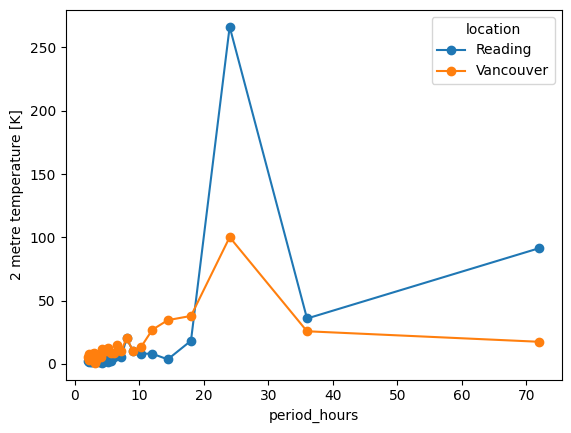

In [4]:
amplitude.plot.line(x="period_hours", hue="location", marker="o")